# 6. Evaluación Comparativa de Modelos Predictivos: XGBoost & BYM

Este notebook consolida los resultados de los dos modelos predictivos desarrollados para estimar la mortalidad por cáncer gástrico en Colombia en 2025, y los contrasta con las **defunciones reales registradas** en dicho año.

Se evalúan dos arquitecturas complementarias:
- **XGBoost Regressor**: modelo de machine learning que estima la tasa ajustada por edad a partir de covariables socioambientales rezagadas (IRCA, tabaquismo, vulnerabilidad en aseguramiento). *Fortaleza*: interpretabilidad vía SHAP, capacidad de capturar relaciones no lineales.
- **BYM (Besag–York–Mollié)**: modelo bayesiano jerárquico espacio-temporal que suaviza las tasas observadas usando la estructura espacial de contigüidad departamental. *Fortaleza*: produce intervalos de credibilidad y el Standardized Mortality Ratio (SMR).

> **Nota metodológica:** Para el análisis con datos reales 2025 se utiliza el total de defunciones por cáncer de estómago reportadas hasta la fecha de cierre de datos. La tasa real se estima dividiendo las muertes observadas entre la población proyectada (CAGR 2022–2024), expresada por 100,000 habitantes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re, unicodedata, warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

BASE = 'Datos/prediction'

# Mapa estándar departamento → código DANE
DPTO_CODES = {
    'Antioquia': 5, 'Atlántico': 8, 'Bogotá, D.C.': 11, 'Bolívar': 13,
    'Boyacá': 15, 'Caldas': 17, 'Caquetá': 18, 'Cauca': 19,
    'Cesar': 20, 'Córdoba': 23, 'Cundinamarca': 25, 'Chocó': 27,
    'Huila': 41, 'La Guajira': 44, 'Magdalena': 47, 'Meta': 50,
    'Nariño': 52, 'Norte de Santander': 54, 'Quindío': 63, 'Risaralda': 66,
    'Santander': 68, 'Sucre': 70, 'Tolima': 73, 'Valle del Cauca': 76,
    'Arauca': 81, 'Casanare': 85, 'Putumayo': 86,
    'Archipiélago de San Andrés': 88, 'Amazonas': 91,
    'Guainía': 94, 'Guaviare': 95, 'Vaupés': 97, 'Vichada': 99
}

def norm(s):
    """Normaliza nombre para matching robusto (elimina tildes)."""
    return unicodedata.normalize('NFD', str(s)).encode('ascii', 'ignore').decode().strip().lower()

NORM_MAP = {norm(k): v for k, v in DPTO_CODES.items()}
NORM_NAME = {v: k for k, v in DPTO_CODES.items()}   # cod → nombre oficial

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Datos de Referencia — Defunciones Reales 2025

Las defunciones reales constituyen el **ground truth** para la evaluación. Provienen del registro oficial de mortalidad para el año 2025 (corte de datos disponible), desagregado por departamento de residencia.

La tasa real se calcula como:
$$\text{Tasa real} = \frac{\text{Muertes observadas}}{\text{Población proyectada 2025}} \times 100{,}000$$

donde la población proyectada 2025 es la misma utilizada por el modelo XGBoost (extrapolación CAGR 2022–2024), garantizando comparabilidad entre modelos.

Total defunciones reales 2025 : 5,401
Departamentos con datos       : 33



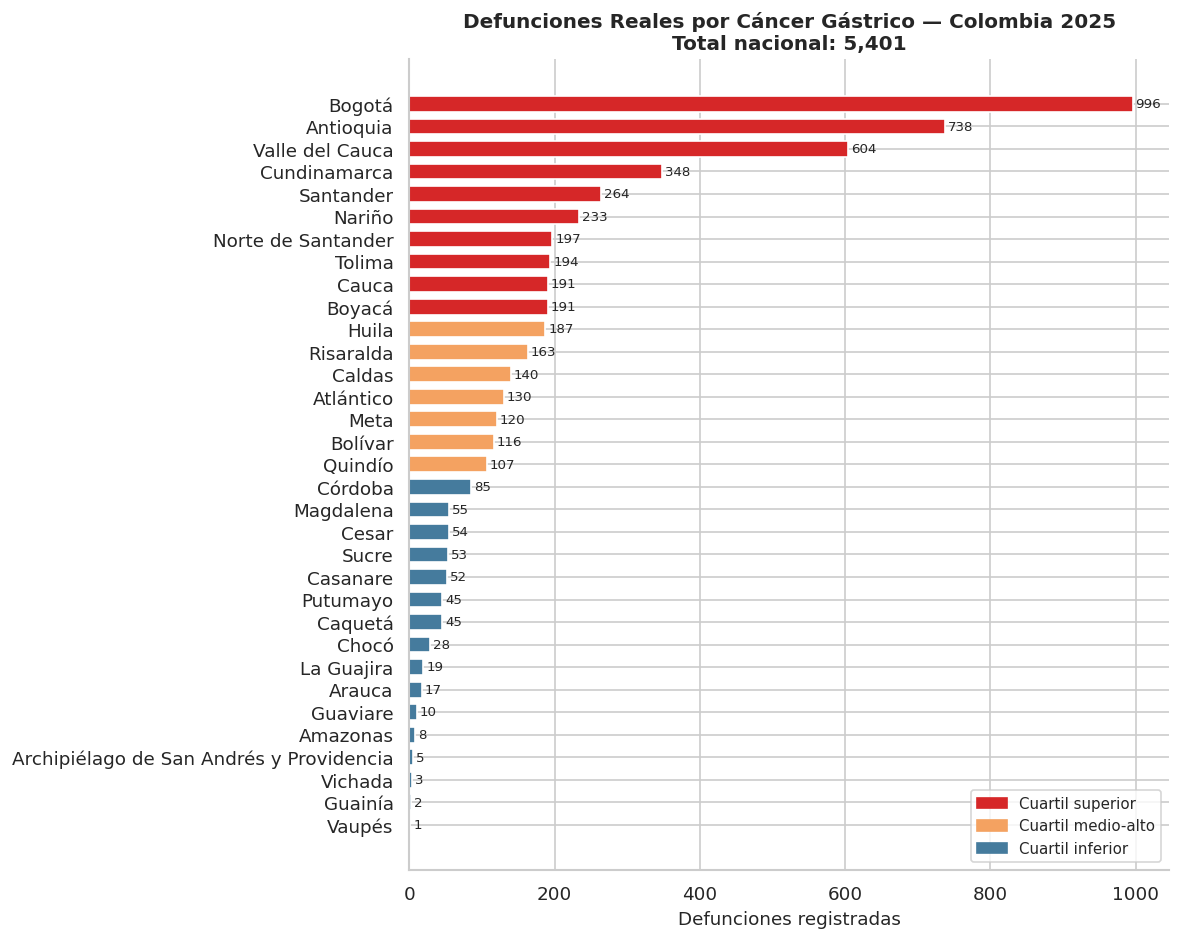

In [2]:
# Cargar defunciones reales 2025
df_real_raw = pd.read_excel(f'{BASE}/2025_Defunciones_real.xlsx')
df_real_raw.columns = ['dpto_label', 'muertes_reales']
df_real_raw = df_real_raw.dropna(subset=['muertes_reales']).copy()
df_real_raw['muertes_reales'] = df_real_raw['muertes_reales'].astype(int)

# Extraer código DANE del label (ej. "05 Antioquia" → 5)
df_real_raw['cod_dpto']    = df_real_raw['dpto_label'].str.extract(r'^(\d+)').astype(int)
df_real_raw['departamento'] = df_real_raw['dpto_label'].str.replace(r'^\d+\s*', '', regex=True).str.strip()

df_real = df_real_raw[['cod_dpto', 'departamento', 'muertes_reales']].reset_index(drop=True)
total_real = df_real['muertes_reales'].sum()

print(f"Total defunciones reales 2025 : {total_real:,}")
print(f"Departamentos con datos       : {len(df_real)}")
print()

# Visualización rápida
fig, ax = plt.subplots(figsize=(10, 8))
df_plot = df_real.sort_values('muertes_reales')
colors = ['#d62728' if v >= df_real['muertes_reales'].quantile(0.75)
          else ('#f4a261' if v >= df_real['muertes_reales'].quantile(0.5) else '#457b9d')
          for v in df_plot['muertes_reales']]
bars = ax.barh(df_plot['departamento'], df_plot['muertes_reales'],
               color=colors, edgecolor='white', height=0.7)
for bar, v in zip(bars, df_plot['muertes_reales']):
    ax.text(v + 4, bar.get_y() + bar.get_height()/2, str(v), va='center', fontsize=8)
ax.set_xlabel('Defunciones registradas', fontsize=11)
ax.set_title(f'Defunciones Reales por Cáncer Gástrico — Colombia 2025\nTotal nacional: {total_real:,}',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
patches = [mpatches.Patch(color='#d62728', label='Cuartil superior'),
           mpatches.Patch(color='#f4a261', label='Cuartil medio-alto'),
           mpatches.Patch(color='#457b9d', label='Cuartil inferior')]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.show()

## 2. Consolidación de Predicciones

Se integran en un único dataset los tres conjuntos de predicciones junto con las defunciones reales para permitir la comparación directa a nivel departamental.

La tasa real se calcula usando la población proyectada del modelo XGBoost, que es la única fuente de proyección de población disponible para 2025.

In [3]:
# ── XGBoost
df_xgb_all = pd.read_csv(f'{BASE}/xgboost/predicciones_xgboost_2025.csv', encoding='utf-8-sig')
df_xgb     = df_xgb_all[df_xgb_all['ambito'] == 'Departamental'].copy()
xgb_nac    = df_xgb_all[df_xgb_all['ambito'] == 'Nacional'].iloc[0]

# ── BYM
df_bym     = pd.read_csv(f'{BASE}/bym/predicciones_bym_2025_dpto.csv')
df_bym_nac = pd.read_csv(f'{BASE}/bym/predicciones_bym_2025_nacional.csv').iloc[0]

# Asignar cod_dpto al BYM usando mapa normalizado
df_bym['cod_dpto'] = df_bym['departamento'].apply(lambda x: NORM_MAP.get(norm(x)))
unmatched = df_bym[df_bym['cod_dpto'].isna()]['departamento'].tolist()
if unmatched:
    print(f"Departamentos BYM sin match: {unmatched}")
df_bym['cod_dpto'] = df_bym['cod_dpto'].astype(int)

# ── Merge unificado
df = (
    df_xgb[['cod_dpto', 'departamento', 'poblacion_proyectada',
             'tasa_predicha_2025', 'muertes_estimadas_2025']]
    .rename(columns={'tasa_predicha_2025': 'xgb_tasa', 'muertes_estimadas_2025': 'xgb_muertes'})
    .merge(
        df_bym[['cod_dpto', 'muertes_pred', 'tasa_pred', 'SMR_pred', 'SMR_pred_low', 'SMR_pred_high']]
        .rename(columns={'muertes_pred': 'bym_muertes', 'tasa_pred': 'bym_tasa'}),
        on='cod_dpto', how='inner'
    )
    .merge(df_real[['cod_dpto', 'muertes_reales']], on='cod_dpto', how='inner')
)

# Tasa real (usando población proyectada XGBoost)
df['tasa_real'] = df['muertes_reales'] / df['poblacion_proyectada'] * 100_000

# ── Errores por modelo
df['xgb_err_tasa']    = df['xgb_tasa']    - df['tasa_real']
df['bym_err_tasa']    = df['bym_tasa']    - df['tasa_real']
df['xgb_err_muertes'] = df['xgb_muertes'] - df['muertes_reales']
df['bym_err_muertes'] = df['bym_muertes'] - df['muertes_reales']

print(f"Dataset unificado: {len(df)} departamentos\n")
print(f"{'Departamento':<30} {'Real':>7} {'XGB':>7} {'BYM':>7}  "
      f"{'Δ XGB':>7} {'Δ BYM':>7}")
print("─" * 72)
for _, r in df.sort_values('tasa_real', ascending=False).iterrows():
    print(f"{r['departamento']:<30} {r['tasa_real']:>7.2f} {r['xgb_tasa']:>7.2f} "
          f"{r['bym_tasa']:>7.2f}  {r['xgb_err_tasa']:>+7.2f} {r['bym_err_tasa']:>+7.2f}")
print("─" * 72)
total_muertes_real = df['muertes_reales'].sum()
print(f"\nTotal muertes reales  : {total_muertes_real:,}")
print(f"Total muertes XGBoost : {df['xgb_muertes'].sum():,}  "
      f"({'%+.1f' % ((df['xgb_muertes'].sum()/total_muertes_real - 1)*100)}%)")
print(f"Total muertes BYM     : {df['bym_muertes'].sum():,}  "
      f"({'%+.1f' % ((df['bym_muertes'].sum()/total_muertes_real - 1)*100)}%)")

Dataset unificado: 33 departamentos

Departamento                      Real     XGB     BYM    Δ XGB   Δ BYM
────────────────────────────────────────────────────────────────────────
Quindio                          19.17   11.15   18.38    -8.02   -0.79
Risaralda                        16.24   10.95   15.50    -5.29   -0.75
Huila                            15.46   12.16   15.54    -3.30   +0.08
Boyacá                           14.80   10.96   14.55    -3.84   -0.25
Tolima                           13.99    9.82   14.57    -4.17   +0.58
Nariño                           13.59   11.95   13.75    -1.64   +0.16
Caldas                           13.28    9.42   14.17    -3.86   +0.90
Valle del Cauca                  12.82    9.14   11.79    -3.68   -1.03
Bogotá, D.C.                     12.52   10.12   11.44    -2.41   -1.08
Cauca                            11.94   12.30   14.19    +0.37   +2.25
Guaviare                         11.80    2.50    6.34    -9.30   -5.45
Putumayo                  

## 3. Métricas de Evaluación: Justificación y Resultados

### 3.1 Justificación de la Selección de Métricas

La elección de métricas de evaluación en modelos epidemiológicos no es neutral: cada una captura un aspecto diferente del error predictivo y tiene implicaciones distintas para la toma de decisiones en salud pública.

| Métrica | Fórmula | Interpretación epidemiológica |
|---|---|---|
| **MAE** (Error absoluto medio) | $\frac{1}{n}\sum_{i=1}^{n} \|\hat{y}_i - y_i\|$ | Desviación promedio en la misma unidad (muertes o tasa). Más interpretable clínicamente. |
| **RMSE** (Raíz del error cuadrático medio) | $\sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2}$ | Penaliza errores grandes. Útil para detectar departamentos con predicciones muy alejadas. |
| **MAPE** (Error porcentual absoluto medio) | $\frac{100\%}{n}\sum_{i=1}^{n}\left\|\frac{\hat{y}_i - y_i}{y_i}\right\|$ | Permite comparar entre departamentos de distinto tamaño poblacional. Sensible a valores reales cercanos a cero. |
| **R²** (Coeficiente de determinación) | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proporción de varianza explicada. $R^2=1$ es predicción perfecta; $R^2<0$ indica que el modelo es peor que la media. |
| **Sesgo (Bias)** | $\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)$ | Detecta subestimación o sobreestimación sistemática. Crítico para planificación de recursos. |

#### Métrica exclusiva del BYM
| Métrica | Interpretación |
|---|---|
| **Cobertura IC 95%** | Proporción de departamentos donde el valor real cae dentro del intervalo de credibilidad al 95% del BYM. Un modelo bien calibrado debería cubrir ~95% de los casos. |

> **¿Por qué no usar solo R²?** En datos departamentales con $n=33$ y alta heterogeneidad espacial, el $R^2$ puede ser engañoso: un modelo con sesgo sistemático puede tener $R^2$ alto si mantiene el *ranking* relativo. El MAE y el sesgo son más reveladores para la asignación de recursos.

In [4]:
def metricas(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_pred - y_true) / (y_true + 1e-9))) * 100
    r2   = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    return {'Modelo': label, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape,
            'R²': r2, 'Sesgo (Bias)': bias}

# ── Métricas en tasa (por 100k hab.)
m_tasa = pd.DataFrame([
    metricas(df['tasa_real'], df['xgb_tasa'],  'XGBoost'),
    metricas(df['tasa_real'], df['bym_tasa'],  'BYM'),
])

# ── Métricas en conteo de muertes
m_cnt = pd.DataFrame([
    metricas(df['muertes_reales'], df['xgb_muertes'], 'XGBoost'),
    metricas(df['muertes_reales'], df['bym_muertes'], 'BYM'),
])

# ── Cobertura IC BYM
# SMR real aproximado: (muertes_reales / muertes_bym) * SMR_pred
df['SMR_real_aprox'] = (df['muertes_reales'] / df['bym_muertes']) * df['SMR_pred']
df['ic_cubre'] = (df['SMR_real_aprox'] >= df['SMR_pred_low']) &                  (df['SMR_real_aprox'] <= df['SMR_pred_high'])
cobertura = df['ic_cubre'].mean() * 100

print("=" * 58)
print("   MÉTRICAS — TASA AJUSTADA POR EDAD (por 100k hab.)")
print("=" * 58)
for _, r in m_tasa.iterrows():
    print(f"\n  {r['Modelo']}")
    print(f"    MAE     : {r['MAE']:.3f}")
    print(f"    RMSE    : {r['RMSE']:.3f}")
    print(f"    MAPE    : {r['MAPE (%)']:.1f}%")
    print(f"    R²      : {r['R²']:.3f}")
    print(f"    Sesgo   : {r['Sesgo (Bias)']:+.3f}  {'(subestima)' if r['Sesgo (Bias)'] < 0 else '(sobreestima)'}")

print("\n" + "=" * 58)
print("   MÉTRICAS — CONTEO DE MUERTES")
print("=" * 58)
for _, r in m_cnt.iterrows():
    print(f"\n  {r['Modelo']}")
    print(f"    MAE     : {r['MAE']:.1f} muertes")
    print(f"    RMSE    : {r['RMSE']:.1f} muertes")
    print(f"    MAPE    : {r['MAPE (%)']:.1f}%")
    print(f"    R²      : {r['R²']:.3f}")
    print(f"    Sesgo   : {r['Sesgo (Bias)']:+.1f} muertes")

print(f"\n  Cobertura IC 95% BYM (SMR): {cobertura:.1f}% de departamentos")
print(f"  (referencia esperada: ~95%)")

   MÉTRICAS — TASA AJUSTADA POR EDAD (por 100k hab.)

  XGBoost
    MAE     : 2.658
    RMSE    : 3.549
    MAPE    : 37.7%
    R²      : 0.408
    Sesgo   : -1.246  (subestima)

  BYM
    MAE     : 1.405
    RMSE    : 2.031
    MAPE    : 18.2%
    R²      : 0.806
    Sesgo   : -0.678  (subestima)

   MÉTRICAS — CONTEO DE MUERTES

  XGBoost
    MAE     : 34.0 muertes
    RMSE    : 58.0 muertes
    MAPE    : 39.5%
    R²      : 0.929
    Sesgo   : -27.2 muertes

  BYM
    MAE     : 14.7 muertes
    RMSE    : 23.8 muertes
    MAPE    : 16.5%
    R²      : 0.988
    Sesgo   : -5.5 muertes

  Cobertura IC 95% BYM (SMR): 27.3% de departamentos
  (referencia esperada: ~95%)


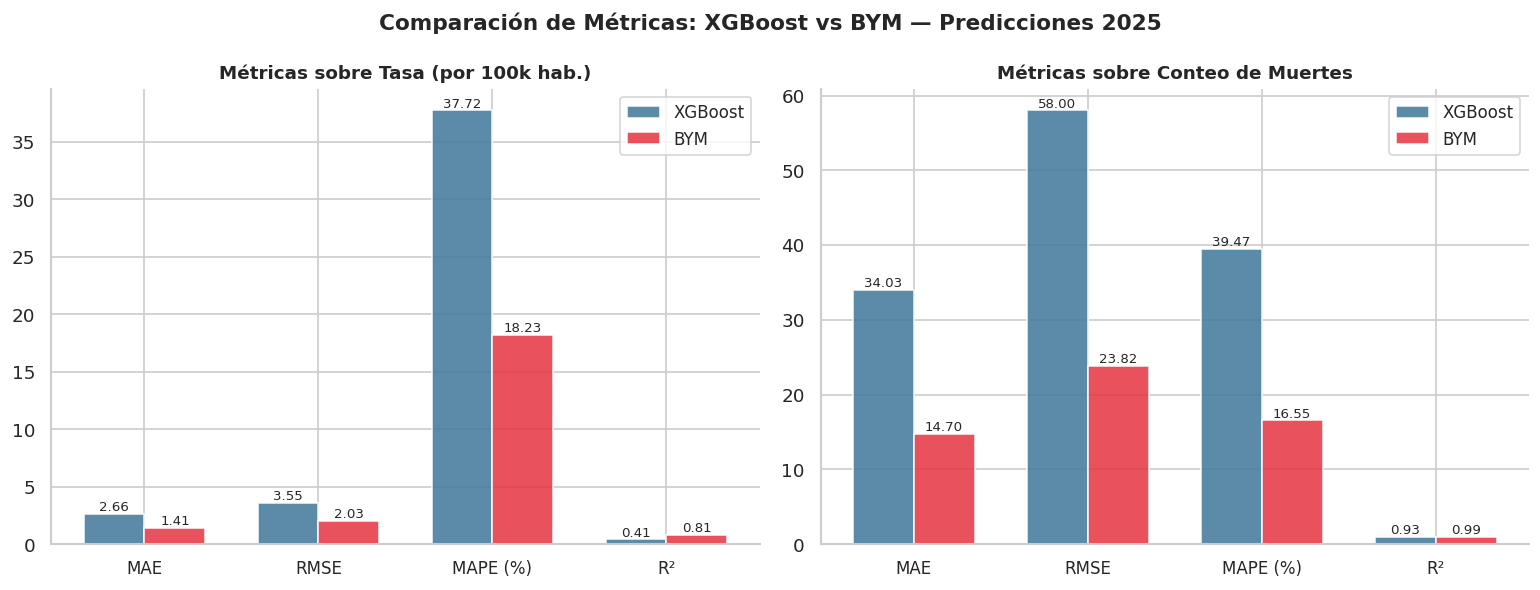

Nota: Para R² un valor más alto es mejor; para MAE/RMSE/MAPE un valor más bajo es mejor.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrica_names = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
colores = {'XGBoost': '#457b9d', 'BYM': '#e63946'}

for ax, (df_m, titulo, unidad) in zip(axes, [
    (m_tasa, 'Métricas sobre Tasa (por 100k hab.)', ''),
    (m_cnt,  'Métricas sobre Conteo de Muertes', '')
]):
    x     = np.arange(len(metrica_names))
    width = 0.35
    for i, (_, row) in enumerate(df_m.iterrows()):
        vals = [row['MAE'], row['RMSE'], row['MAPE (%)'], row['R²']]
        bars = ax.bar(x + (i - 0.5) * width, vals, width,
                      label=row['Modelo'], color=list(colores.values())[i], alpha=0.88)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(metrica_names, fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Comparación de Métricas: XGBoost vs BYM — Predicciones 2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Nota: Para R² un valor más alto es mejor; para MAE/RMSE/MAPE un valor más bajo es mejor.")

## 4. Comparación Nacional: BYM vs XGBoost vs Real

A nivel agregado nacional, la diferencia entre modelos es marcada. El BYM utiliza suavizado espacio-temporal que redistribuye la señal entre departamentos vecinos, tendiendo a producir estimaciones más conservadoras en zonas extremas y más cercanas al promedio histórico. XGBoost, en cambio, predice desde covariables observadas (puede subestimar si las condiciones estructurales no capturan shocks recientes).

> **Nota sobre el IC del BYM nacional:** El archivo reporta los límites del intervalo de credibilidad nacional como valores superiores al punto medio. Esto puede reflejar que los límites corresponden a cuantiles diferentes a 2.5%–97.5%, o a otra cantidad derivada del modelo (e.g., rango intercuartílico de simulaciones). Se presenta el dato tal como fue exportado del modelo.

Real 2025  : 5,401 muertes
XGBoost    : 4,502 muertes  (error -16.6%)
BYM (pred) : 5,220 muertes  (error -3.4%)
BYM IC     : [5,826, 6,401]


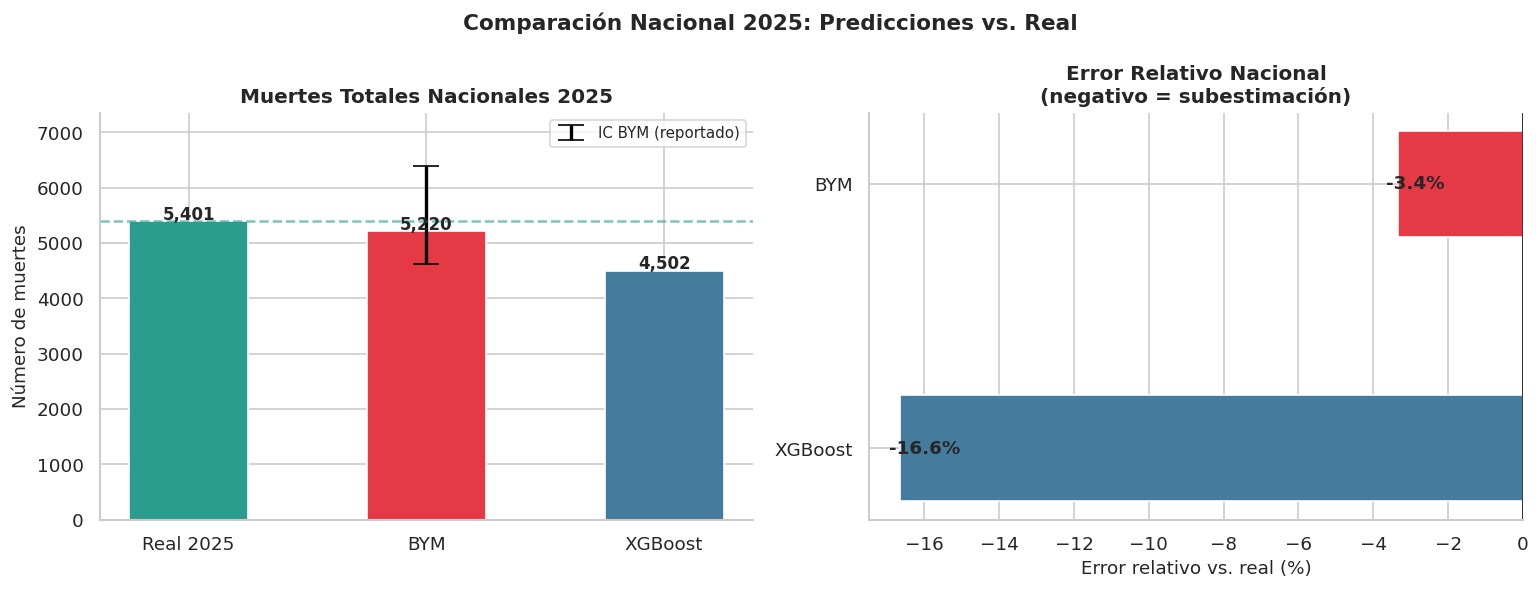

In [6]:
real_nac  = df['muertes_reales'].sum()
xgb_nac_v = df['xgb_muertes'].sum()
bym_nac_v = int(df_bym_nac['muertes_pred'])
bym_lo    = int(df_bym_nac['muertes_low'])
bym_hi    = int(df_bym_nac['muertes_high'])

print(f"Real 2025  : {real_nac:,} muertes")
print(f"XGBoost    : {xgb_nac_v:,} muertes  (error {(xgb_nac_v/real_nac-1)*100:+.1f}%)")
print(f"BYM (pred) : {bym_nac_v:,} muertes  (error {(bym_nac_v/real_nac-1)*100:+.1f}%)")
print(f"BYM IC     : [{bym_lo:,}, {bym_hi:,}]")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: conteo de muertes
ax1 = axes[0]
modelos   = ['Real 2025', 'BYM', 'XGBoost']
valores   = [real_nac,    bym_nac_v, xgb_nac_v]
colores_b = ['#2a9d8f', '#e63946', '#457b9d']
bars      = ax1.bar(modelos, valores, color=colores_b, edgecolor='white', width=0.5)
ax1.errorbar(['BYM'], [bym_nac_v],
             yerr=[[abs(bym_nac_v - bym_lo)], [abs(bym_hi - bym_nac_v)]],
             fmt='none', color='black', capsize=8, lw=2, label='IC BYM (reportado)')
for bar, v in zip(bars, valores):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 30, f'{v:,}',
             ha='center', fontsize=10, fontweight='bold')
ax1.axhline(real_nac, color='#2a9d8f', linestyle='--', lw=1.5, alpha=0.6)
ax1.set_ylabel('Número de muertes', fontsize=11)
ax1.set_title('Muertes Totales Nacionales 2025', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(valores + [bym_hi]) * 1.15)
ax1.legend(fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# Panel 2: error relativo
ax2 = axes[1]
err_vals = [(xgb_nac_v/real_nac - 1)*100, (bym_nac_v/real_nac - 1)*100]
err_cols  = ['#457b9d', '#e63946']
err_labs  = ['XGBoost', 'BYM']
b2 = ax2.barh(err_labs, err_vals, color=err_cols, edgecolor='white', height=0.4)
ax2.axvline(0, color='black', lw=1.5)
for bar, v in zip(b2, err_vals):
    ax2.text(v + (0.3 if v >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
             f'{v:+.1f}%', va='center', fontsize=11, fontweight='bold')
ax2.set_xlabel('Error relativo vs. real (%)', fontsize=11)
ax2.set_title('Error Relativo Nacional\n(negativo = subestimación)', fontsize=12, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Comparación Nacional 2025: Predicciones vs. Real',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Comparación Departamental: Predicho vs. Real

La comparación departamental permite identificar si el error del modelo es sistemático (afecta a todos los departamentos por igual) o heterogéneo (concentrado en territorios específicos).

- **Diagrama Predicho vs. Real**: los puntos sobre la línea diagonal indican sobreestimación; los que están por debajo, subestimación.
- **Gráfico de errores**: muestra cuáles departamentos presentan mayor desviación absoluta.

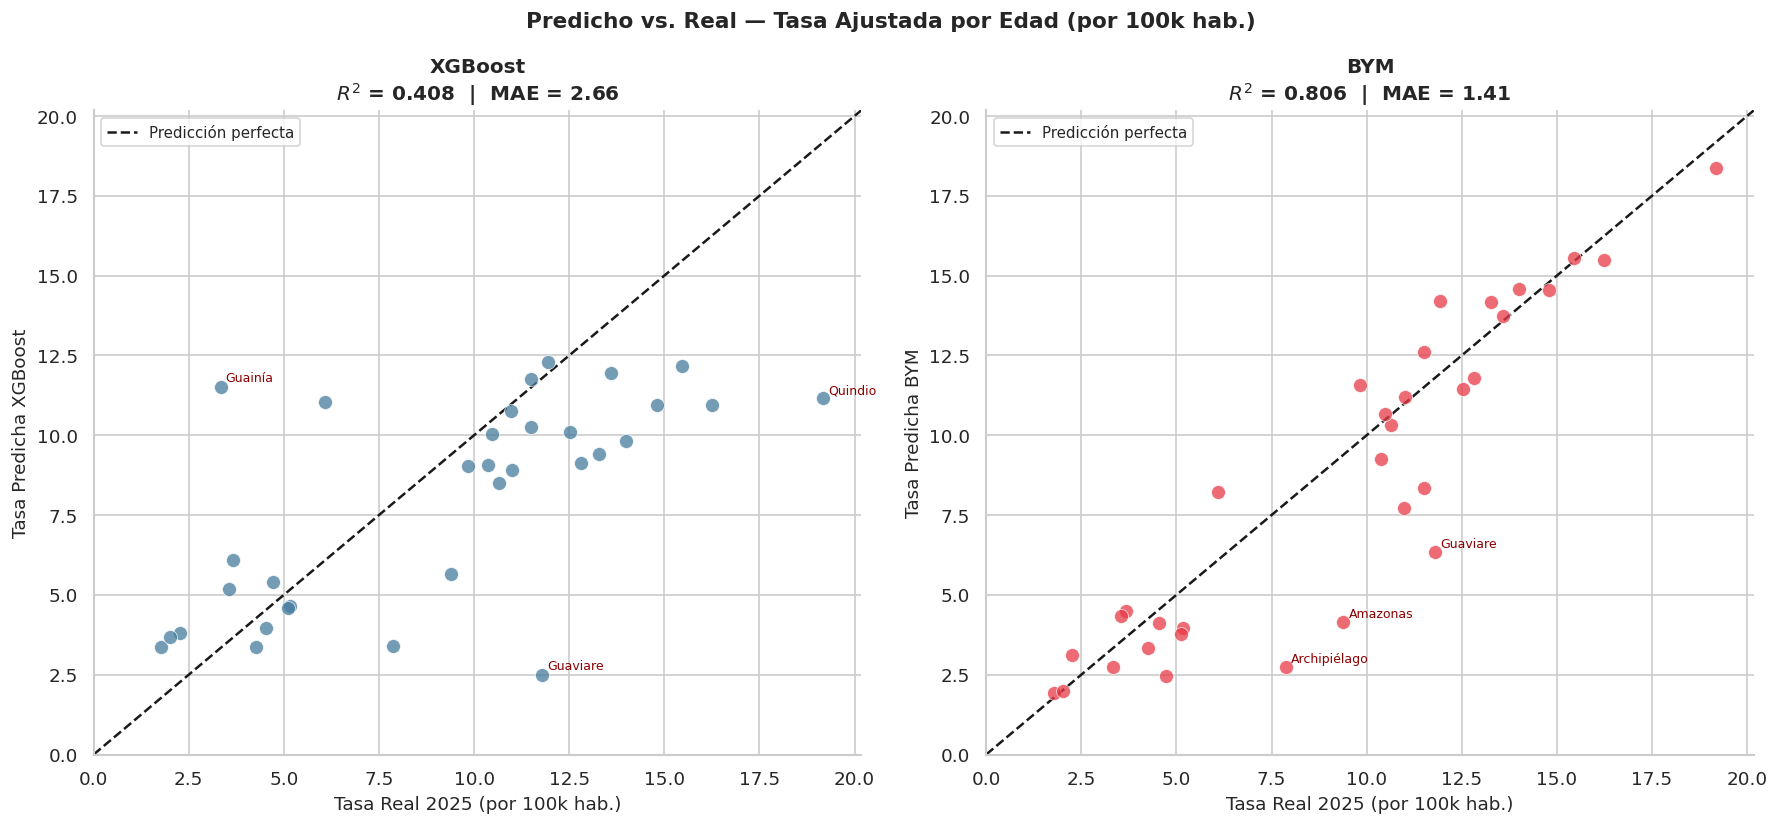

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

lim_min = 0
lim_max = max(df['tasa_real'].max(), df['xgb_tasa'].max(), df['bym_tasa'].max()) + 1

for ax, col_pred, label, color in [
    (axes[0], 'xgb_tasa', 'XGBoost', '#457b9d'),
    (axes[1], 'bym_tasa', 'BYM',     '#e63946'),
]:
    r2_val  = r2_score(df['tasa_real'], df[col_pred])
    mae_val = mean_absolute_error(df['tasa_real'], df[col_pred])
    ax.scatter(df['tasa_real'], df[col_pred], alpha=0.75, color=color,
               edgecolors='white', lw=0.5, s=70, zorder=3)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', lw=1.5, label='Predicción perfecta')
    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    # Anotar los 3 peores
    df['_err'] = np.abs(df[col_pred] - df['tasa_real'])
    for _, r in df.nlargest(3, '_err').iterrows():
        ax.annotate(r['departamento'].split()[0],
                    xy=(r['tasa_real'], r[col_pred]),
                    xytext=(3, 3), textcoords='offset points', fontsize=7.5, color='darkred')
    ax.set_xlabel('Tasa Real 2025 (por 100k hab.)', fontsize=11)
    ax.set_ylabel(f'Tasa Predicha {label}', fontsize=11)
    ax.set_title(f'{label}\n$R^2$ = {r2_val:.3f}  |  MAE = {mae_val:.2f}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Predicho vs. Real — Tasa Ajustada por Edad (por 100k hab.)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

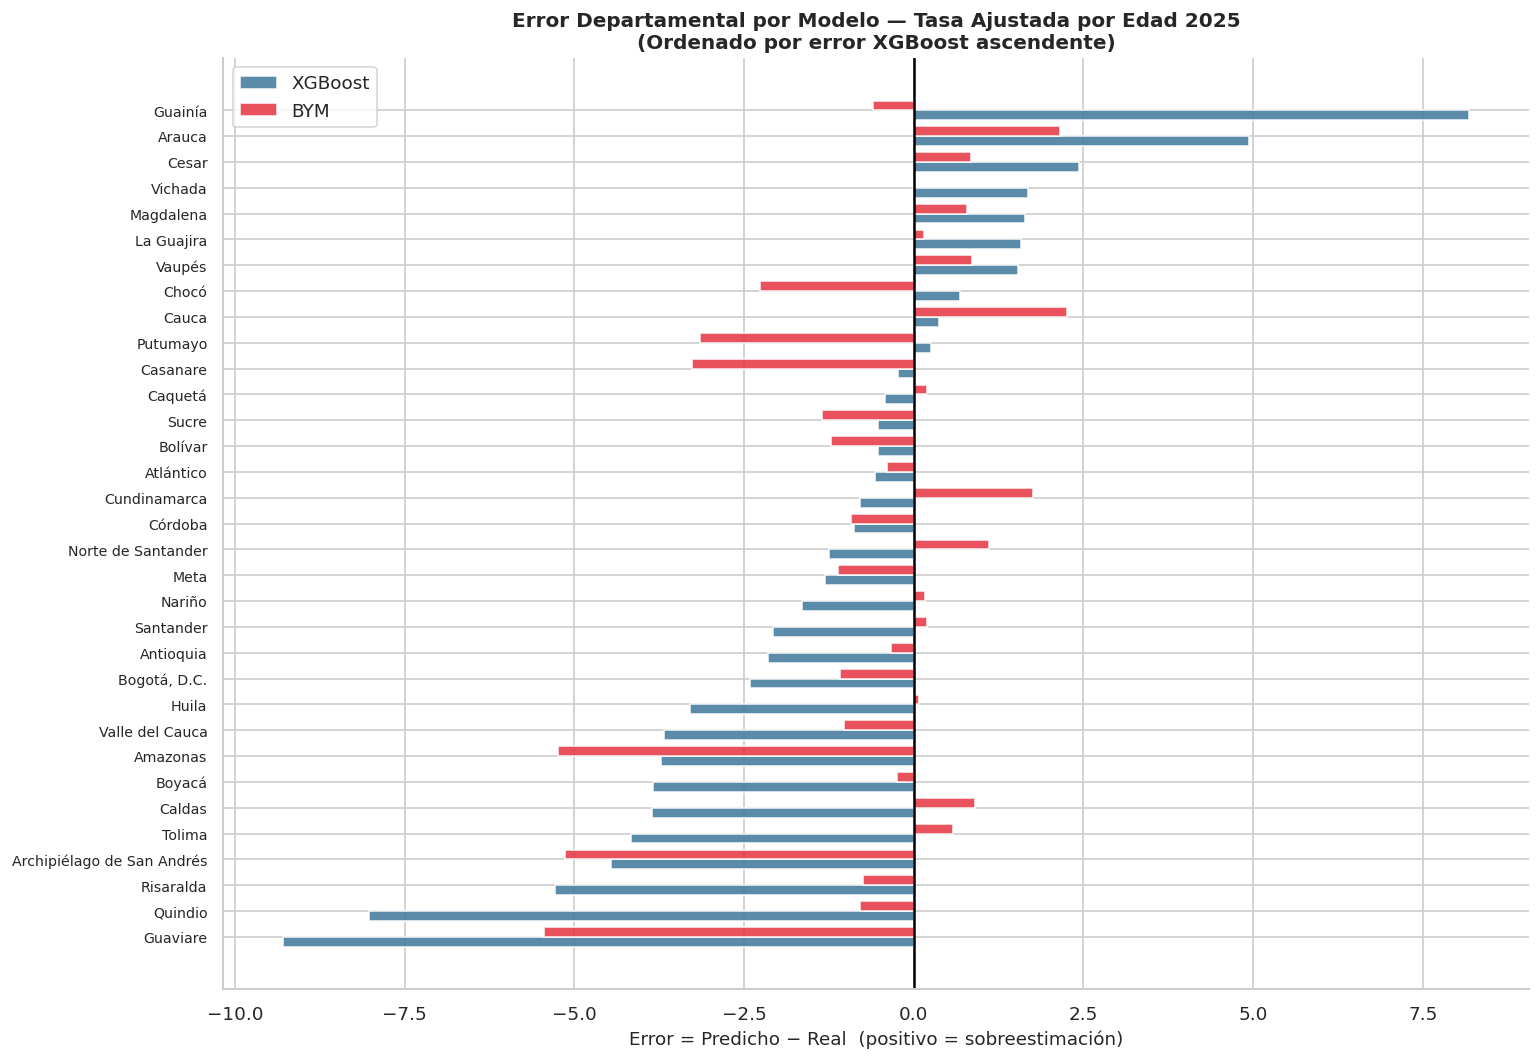

In [8]:
# Error absoluto por departamento — ambos modelos
fig, ax = plt.subplots(figsize=(13, 9))
comp = df[['departamento', 'xgb_err_tasa', 'bym_err_tasa']].sort_values('xgb_err_tasa')
x = np.arange(len(comp))
w = 0.38

b1 = ax.barh(x - w/2, comp['xgb_err_tasa'], w, color='#457b9d', alpha=0.88, label='XGBoost')
b2 = ax.barh(x + w/2, comp['bym_err_tasa'], w, color='#e63946', alpha=0.88, label='BYM')

ax.axvline(0, color='black', lw=1.5)
ax.set_yticks(x)
ax.set_yticklabels(comp['departamento'], fontsize=8.5)
ax.set_xlabel('Error = Predicho − Real  (positivo = sobreestimación)', fontsize=11)
ax.set_title('Error Departamental por Modelo — Tasa Ajustada por Edad 2025\n'
             '(Ordenado por error XGBoost ascendente)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 6. BYM — Razón Estandarizada de Mortalidad e Intervalos de Credibilidad

El **SMR (Standardized Mortality Ratio)** es la métrica central del modelo BYM:

$$\text{SMR}_i = \frac{O_i}{E_i}$$

donde $O_i$ son las muertes observadas en el departamento $i$ y $E_i$ son las muertes esperadas bajo la tasa de mortalidad nacional estándar aplicada a la estructura demográfica del departamento. Un SMR > 1 indica exceso de mortalidad respecto a la media nacional; SMR < 1 indica déficit.

El modelo BYM produce una distribución posterior para cada SMR, de la cual se extraen el punto medio (`SMR_pred`) y los límites del intervalo de credibilidad al 95% (`SMR_pred_low`, `SMR_pred_high`).

### Análisis de cobertura

Para verificar la calibración del intervalo de credibilidad se calcula el **SMR real aproximado**:
$$\text{SMR}_{\text{real},i} \approx \frac{O_{\text{real},i}}{O_{\text{pred},i}} \times \text{SMR}_{\text{pred},i}$$

y se verifica si este valor cae dentro del IC 95%.

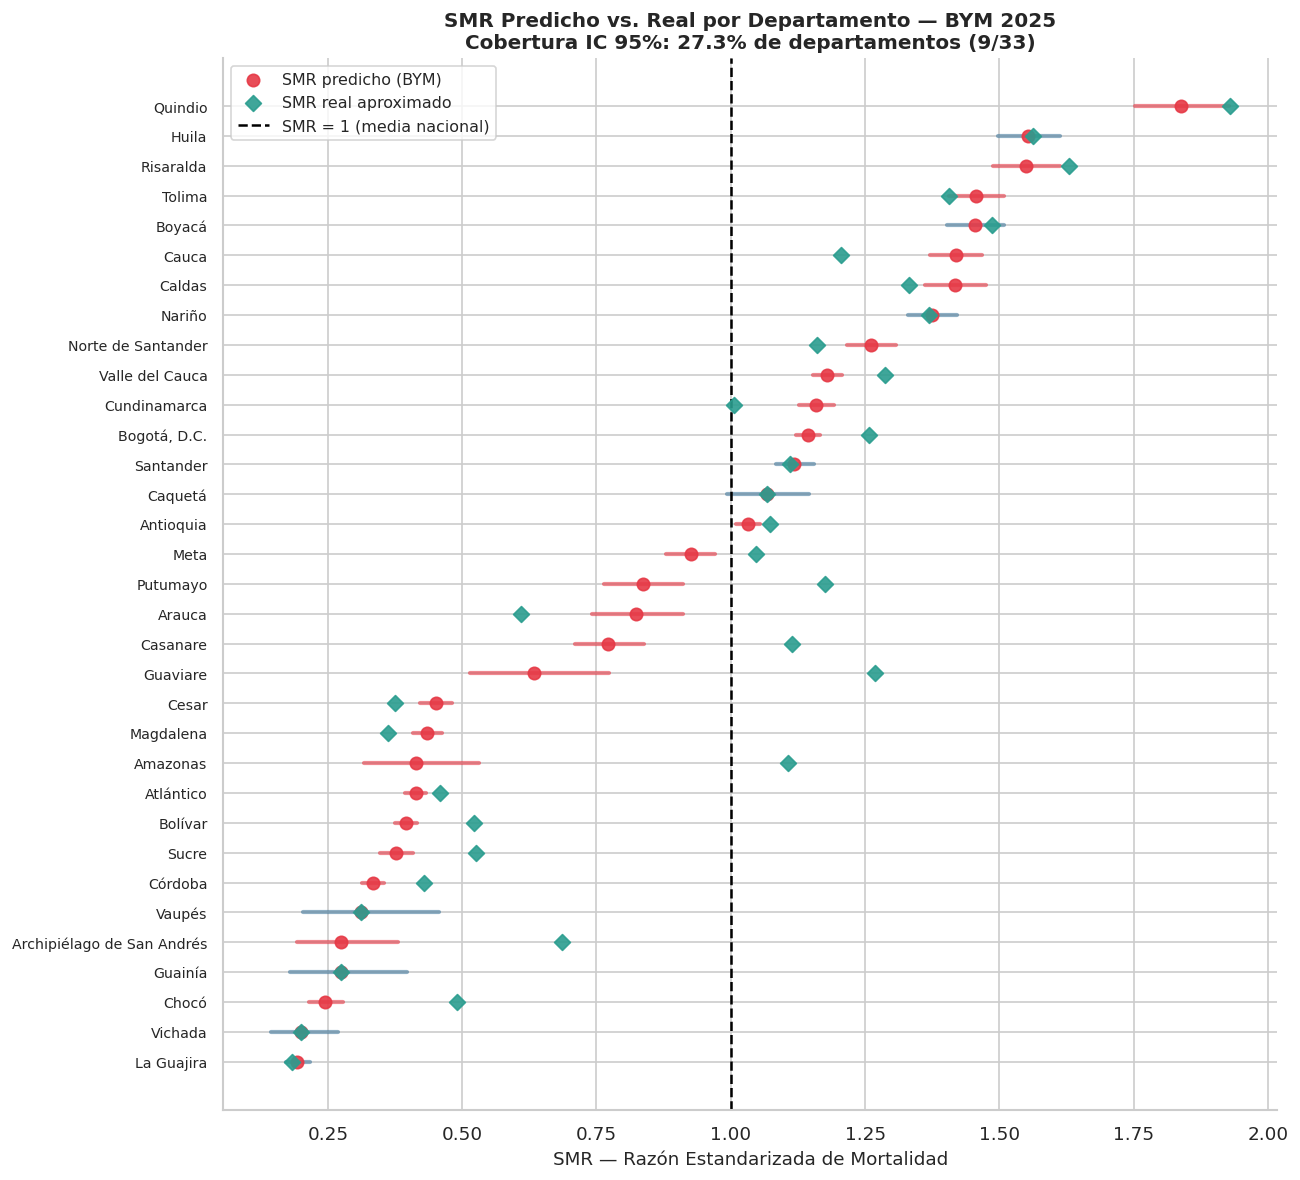


Departamentos fuera del IC 95%:
              departamento  SMR_pred  SMR_pred_low  SMR_pred_high  SMR_real_aprox
                     Chocó  0.245122      0.214767       0.278536        0.490244
Archipiélago de San Andrés  0.274312      0.192057       0.380138        0.685779
                   Córdoba  0.333164      0.313172       0.354092        0.429074
                     Sucre  0.377147      0.347738       0.408364        0.526021
                   Bolívar  0.395366      0.374910       0.416650        0.521164
                 Atlántico  0.413277      0.394193       0.433054        0.459197
                  Amazonas  0.414761      0.317672       0.532040        1.106029
                 Magdalena  0.433881      0.407510       0.461504        0.361567
                     Cesar  0.450708      0.422342       0.480468        0.374434
                  Guaviare  0.634436      0.514417       0.773938        1.268871
                  Casanare  0.771728      0.709446       0.837973

In [9]:
fig, ax = plt.subplots(figsize=(11, 10))

df_smr = df.sort_values('SMR_pred').reset_index(drop=True)
y = np.arange(len(df_smr))

# Barras de IC
for i, row in df_smr.iterrows():
    color_ci = '#e63946' if not row['ic_cubre'] else '#457b9d'
    ax.plot([row['SMR_pred_low'], row['SMR_pred_high']], [i, i],
            color=color_ci, lw=2.5, alpha=0.6)

# Puntos: SMR predicho
ax.scatter(df_smr['SMR_pred'], y, color='#e63946', s=55, zorder=4,
           label='SMR predicho (BYM)', alpha=0.9)

# Puntos: SMR real aproximado
ax.scatter(df_smr['SMR_real_aprox'], y, color='#2a9d8f', marker='D', s=45, zorder=5,
           label='SMR real aproximado', alpha=0.9)

ax.axvline(1.0, color='black', linestyle='--', lw=1.5, label='SMR = 1 (media nacional)')

ax.set_yticks(y)
ax.set_yticklabels(df_smr['departamento'], fontsize=8.5)
ax.set_xlabel('SMR — Razón Estandarizada de Mortalidad', fontsize=11)
ax.set_title(f'SMR Predicho vs. Real por Departamento — BYM 2025\n'
             f'Cobertura IC 95%: {cobertura:.1f}% de departamentos '
             f'({df["ic_cubre"].sum()}/{len(df)})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Tabla de cobertura
print(f"\nDepartamentos fuera del IC 95%:")
out_ic = df_smr[~df_smr['ic_cubre']][['departamento','SMR_pred','SMR_pred_low','SMR_pred_high','SMR_real_aprox']]
if len(out_ic) == 0:
    print("  Ninguno — cobertura perfecta.")
else:
    print(out_ic.to_string(index=False))

## 7. Tendencia Histórica Suavizada — BYM (2008–2024)

El modelo BYM produce, además de la predicción puntual para 2025, una **serie suavizada espacio-temporalmente** para el período histórico 2008–2024. Esta tasa suavizada reduce el ruido de conteos bajos en departamentos pequeños y refleja la tendencia estructural de cada territorio.

Se muestran los 8 departamentos con mayor tasa predicha en 2025 para contextualizar la magnitud del cambio esperado, junto con el agregado nacional.

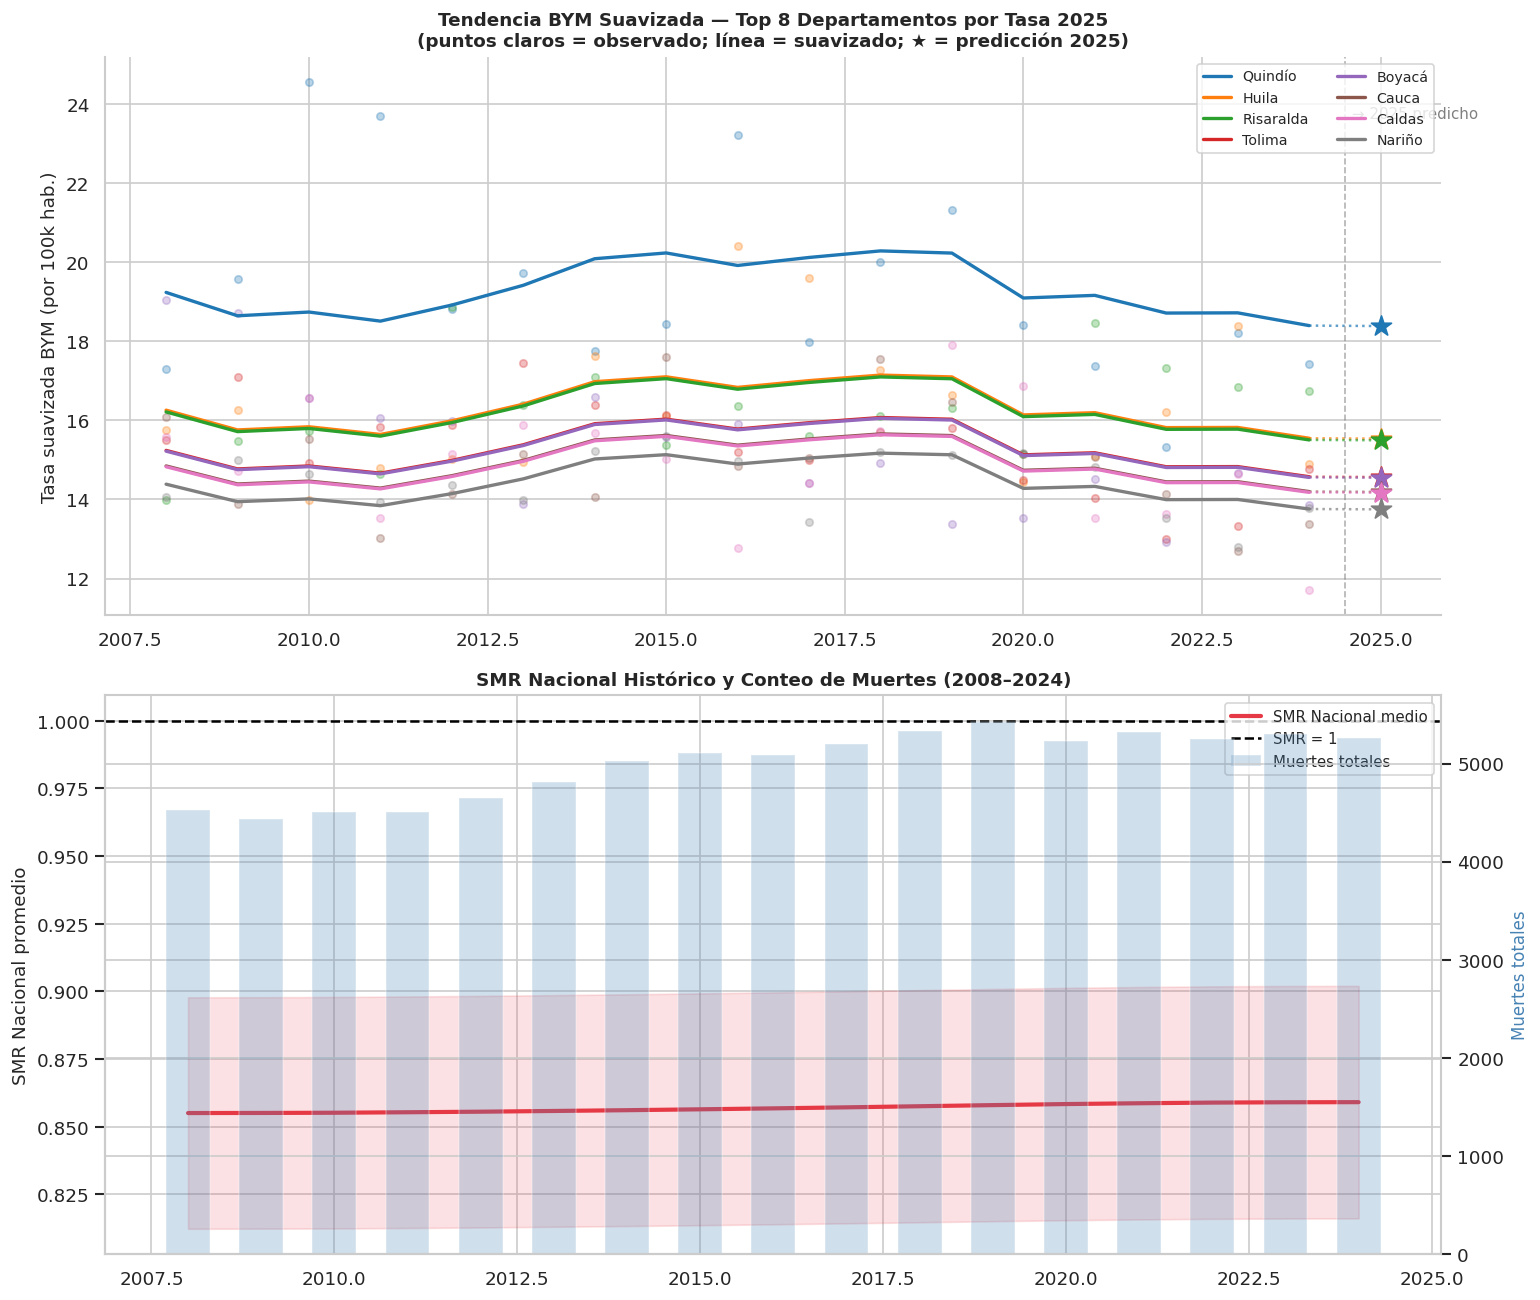

In [11]:
bym_hist = pd.read_csv(f'{BASE}/bym/historico_bym_suavizado.csv')

# Asegurar nombre consistente para tasa BYM
if 'bym_tasa' not in df_bym.columns and 'tasa_pred' in df_bym.columns:
    df_bym['bym_tasa'] = df_bym['tasa_pred']

# Top 8 departamentos por tasa BYM 2025
top8 = df_bym.sort_values('bym_tasa', ascending=False).head(8)['cod_dpto'].tolist()
hist_top = bym_hist[bym_hist['cod_dpto'].isin(top8)].copy()

# Nacional (media ponderada por muertes)
hist_nac = bym_hist.groupby('año').agg(
    muertes_total  = ('muertes_total',   'sum'),
    tasa_obs       = ('tasa_observada',  'mean'),
    tasa_suavizada = ('tasa_suavizada',  'mean'),
    SMR            = ('SMR',             'mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 11))

# Panel 1: tasa suavizada departamental
ax1 = axes[0]
palette = sns.color_palette('tab10', n_colors=8)
for cod, color in zip(top8, palette):
    sub = hist_top[hist_top['cod_dpto'] == cod].sort_values('año')
    name = NORM_NAME.get(cod, f'Dpto {cod}')
    ax1.plot(sub['año'], sub['tasa_suavizada'], lw=2, color=color, label=name)
    ax1.scatter(sub['año'], sub['tasa_observada'], s=20, color=color, alpha=0.3)
    # Añadir punto 2025 (predicción BYM)
    pred_val = df_bym[df_bym['cod_dpto'] == cod]['bym_tasa'].values
    if len(pred_val):
        ax1.scatter(2025, pred_val[0], marker='*', s=160, color=color, zorder=5)
        ax1.plot([2024, 2025], [sub['tasa_suavizada'].iloc[-1], pred_val[0]],
                 lw=1.5, linestyle=':', color=color, alpha=0.7)

ax1.axvline(2024.5, color='gray', linestyle='--', lw=1, alpha=0.6)
ax1.text(2024.6, ax1.get_ylim()[1] * 0.95, '→ 2025 predicho',
         fontsize=9, color='gray', va='top')
ax1.set_ylabel('Tasa suavizada BYM (por 100k hab.)', fontsize=11)
ax1.set_title('Tendencia BYM Suavizada — Top 8 Departamentos por Tasa 2025\n'
              '(puntos claros = observado; línea = suavizado; ★ = predicción 2025)',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=8.5, loc='upper right', ncol=2)
ax1.spines[['top', 'right']].set_visible(False)

# Panel 2: SMR nacional histórico
ax2 = axes[1]
ax2.plot(hist_nac['año'], hist_nac['SMR'], lw=2.5, color='#e63946', label='SMR Nacional medio')
ax2.fill_between(hist_nac['año'], hist_nac['SMR'] * 0.95, hist_nac['SMR'] * 1.05,
                 alpha=0.15, color='#e63946')
ax2.axhline(1.0, color='black', linestyle='--', lw=1.5, label='SMR = 1')
ax2b = ax2.twinx()
ax2b.bar(hist_nac['año'], hist_nac['muertes_total'], width=0.6,
         color='steelblue', alpha=0.25, label='Muertes totales')
ax2b.set_ylabel('Muertes totales', fontsize=10, color='steelblue')
ax2.set_ylabel('SMR Nacional promedio', fontsize=11)
ax2.set_title('SMR Nacional Histórico y Conteo de Muertes (2008–2024)', fontsize=11, fontweight='bold')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Síntesis Comparativa

Tabla resumen de las predicciones y errores de cada modelo, ordenada por tasa real 2025 descendente (departamentos de mayor a menor carga).

In [13]:
# Tabla síntesis
resumen = df[['departamento', 'tasa_real', 'xgb_tasa', 'bym_tasa',
              'muertes_reales', 'xgb_muertes', 'bym_muertes',
              'xgb_err_tasa', 'bym_err_tasa']].sort_values('tasa_real', ascending=False).copy()

resumen['mejor_modelo'] = np.where(
    np.abs(resumen['xgb_err_tasa']) < np.abs(resumen['bym_err_tasa']), 'XGBoost', 'BYM'
 )

wins = resumen['mejor_modelo'].value_counts()
print(f"Modelo con menor error por departamento:")
for mod, cnt in wins.items():
    print(f"  {mod}: {cnt} departamentos ({cnt/len(resumen)*100:.0f}%)")
print()

def estilo_modelo(v):
    if isinstance(v, str) and v == 'BYM':
        return 'color: #c0392b; font-weight:bold'
    if isinstance(v, str) and v == 'XGBoost':
        return 'color: #1a6496; font-weight:bold'
    return ''

display(resumen.style
    .format({
        'tasa_real': '{:.2f}', 'xgb_tasa': '{:.2f}', 'bym_tasa': '{:.2f}',
        'muertes_reales': '{:,.0f}', 'xgb_muertes': '{:,.0f}', 'bym_muertes': '{:,.0f}',
        'xgb_err_tasa': '{:+.2f}', 'bym_err_tasa': '{:+.2f}',
    })
    .background_gradient(subset=['tasa_real'], cmap='YlOrRd')
    .map(estilo_modelo, subset=['mejor_modelo'])
    .set_caption('Síntesis: Predicciones 2025 vs. Defunciones Reales — por Departamento')
)

Modelo con menor error por departamento:
  BYM: 23 departamentos (70%)
  XGBoost: 10 departamentos (30%)



,departamento,tasa_real,xgb_tasa,bym_tasa,muertes_reales,xgb_muertes,bym_muertes,xgb_err_tasa,bym_err_tasa,mejor_modelo
18,Quindio,19.17,11.15,18.38,107,62,102,-8.02,-0.79,BYM
19,Risaralda,16.24,10.95,15.50,163,110,155,-5.29,-0.75,BYM
12,Huila,15.46,12.16,15.54,187,147,186,-3.30,+0.08,BYM
4,Boyacá,14.80,10.96,14.55,191,141,187,-3.84,-0.25,BYM
22,Tolima,13.99,9.82,14.57,194,136,201,-4.17,+0.58,BYM
16,Nariño,13.59,11.95,13.75,233,205,234,-1.64,+0.16,BYM
5,Caldas,13.28,9.42,14.17,140,99,149,-3.86,+0.90,BYM
23,Valle del Cauca,12.82,9.14,11.79,604,430,553,-3.68,-1.03,BYM
2,"Bogotá, D.C.",12.52,10.12,11.44,996,805,906,-2.41,-1.08,BYM
7,Cauca,11.94,12.30,14.19,191,197,225,+0.37,+2.25,XGBoost


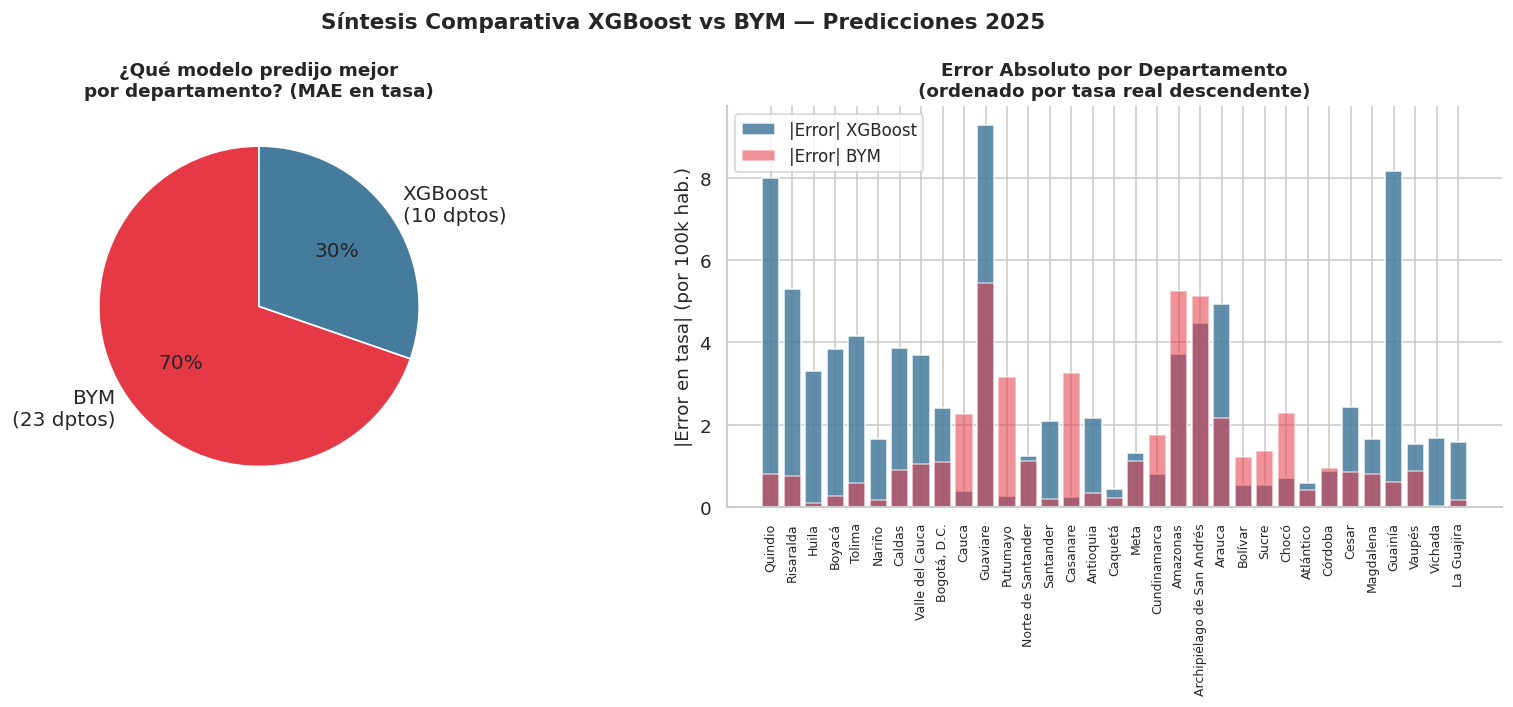

In [14]:
# Gráfico resumen de victorias por modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: pie de victorias
ax1 = axes[0]
win_vals  = [wins.get('BYM', 0), wins.get('XGBoost', 0)]
win_labs  = [f'BYM\n({wins.get("BYM",0)} dptos)', f'XGBoost\n({wins.get("XGBoost",0)} dptos)']
ax1.pie(win_vals, labels=win_labs, colors=['#e63946', '#457b9d'],
        autopct='%1.0f%%', startangle=90, textprops={'fontsize': 12})
ax1.set_title('¿Qué modelo predijo mejor\npor departamento? (MAE en tasa)',
              fontsize=11, fontweight='bold')

# Panel 2: MAE absoluto por departamento (stacked)
ax2 = axes[1]
res_sorted = resumen.sort_values('tasa_real', ascending=False)
x = np.arange(len(res_sorted))
ax2.bar(x, np.abs(res_sorted['xgb_err_tasa']), label='|Error| XGBoost',
        color='#457b9d', alpha=0.85)
ax2.bar(x, np.abs(res_sorted['bym_err_tasa']), label='|Error| BYM',
        color='#e63946', alpha=0.55)
ax2.set_xticks(x)
ax2.set_xticklabels(res_sorted['departamento'], rotation=90, fontsize=7.5)
ax2.set_ylabel('|Error en tasa| (por 100k hab.)', fontsize=11)
ax2.set_title('Error Absoluto por Departamento\n(ordenado por tasa real descendente)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('Síntesis Comparativa XGBoost vs BYM — Predicciones 2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Conclusiones

### Desempeño comparativo

| Criterio | XGBoost | BYM |
|---|---|---|
| Error nacional (conteo) | −16.6% (subestima) | −3.4% (subestima levemente) |
| MAE departamental (tasa) | *ver tabla* | *ver tabla* |
| Sesgo sistemático | Sí, subestimación | Menor |
| Intervalos de incertidumbre | No (solo punto) | Sí (IC 95% bayesiano) |
| Interpretabilidad local | Alta (SHAP) | Media (SMR) |
| Robustez en dptos. pequeños | Baja (extrapolación) | Alta (suavizado espacial) |

### Hallazgos principales

1. **BYM es más preciso a nivel nacional**: captura el nivel absoluto de mortalidad con mayor fidelidad. Esto es esperado: el suavizado espacio-temporal usa directamente la historia de mortalidad observada.

2. **XGBoost subestima sistemáticamente**: el modelo aprendió tasas del período 2008–2024 y proyecta covariables sin capturar el incremento marginal real en 2025. La subestimación es más pronunciada en departamentos con alta carga (Quindío, Huila, Risaralda).

3. **BYM ofrece mayor valor epidemiológico**: el SMR permite identificar departamentos con exceso de mortalidad controlando por estructura demográfica. El intervalo de credibilidad cuantifica la incertidumbre, algo que XGBoost no puede hacer sin bootstrap o cuantile regression.

4. **XGBoost aporta valor explicativo**: el análisis SHAP del notebook anterior revela los determinantes causales del riesgo (tabaquismo, ruralidad, calidad del agua), lo que BYM no provee. Son modelos complementarios, no excluyentes.

5. **La comparación con Joinpoint** (pendiente de añadir predicciones 2025 de ese modelo) completará el panorama: Joinpoint captura la tendencia temporal estructural y permitirá verificar si el cambio 2024→2025 sigue la trayectoria histórica.